## Zhang et al. (2024) – Cotton Stalk HTL with Oxides & Acids/Bases

**Paper:** Investigation of Cotton Stalk-Derived Hydrothermal Bio-Oil: Effects of Mineral Acid/Base and Oxide Additions  
**DOI:** 10.3390/en17194854  
**Journal:** Energies, 17(19), 4854

### Overview
This notebook ingests experimental data from Zhang et al. (2024) on hydrothermal liquefaction (HTL) of cotton stalk with various catalysts:
- **Oxide screening**: SiO₂, TiO₂ (rutile/anatase), CeO₂, Al₂O₃, ZnO, MgO
- **CeO₂ dosage optimization**: 0.0–1.6 g
- **Acid/base screening**: H₂SO₄, HCl, HNO₃, NaOH, Na₂CO₃, K₂CO₃, KOH (all at 1 M)
- **NaOH concentration sweep**: 0.0–1.0 M

### Notebook Structure
1. **Helper functions and schema**: Data ingestion utilities and canonical column definitions
2. **Data tables**: Digitized yields from Figures 3-5 and elemental composition from Table 1
3. **Visualization**: Reproduce paper figures (oxide screen, CeO₂ dosage, acid/base effects)
4. **Data ingestion**: Build dataset with yields, composition, and operational conditions
5. **Catalyst ratio estimation**: Derive catalyst-to-biomass ratios from supplementary data
6. **Quality assurance**: Validation checks, QA plots, and envelope checks
7. **Final output**: CSV export for master dataset integration

In [1]:
import pandas as pd, numpy as np, json
from pathlib import Path

COLUMNS = [
    # Provenance / source
    "DOI","Provenance","Ref","Source_Figure","Paper_Title",

    # Process
    "Process_type","Process_subtype",

    # Feed descriptor
    "Feedstock","Family","Tier",

    # Operating conditions
    "T","t","IC","Pressure","Solvent_or_medium","Reactor","Separation_method",
    "Yield_basis","Catalyst","Catalyst_Biomass_ratio",
    "Heating_rate","Stirring_velocity","Water_Biomass_ratio","atmosphere",

    # Feed chemistry (ultimate / proximate / components)
    "C","H","O","N","S","Ash","O/C","H/C","HHV_input",
    "Lignin","Cellulose_pct","Hemicellulose_pct","Extractives_pct",
    "Moisture_min","Moisture_max",

    # Product yields
    "B_Y","C_Y","A_Y","G_Y","GW_Y",

    # Energy & carbon balances
    "E_B","E_H","C_B","C_H",

    # Bio-oil properties (daf unless specified)
    "HHV_biooil","C_biooil","H_biooil","O_biooil","N_biooil","S_biooil",

    # Bio-char properties (daf unless specified)
    "HHV_biochar","C_biochar","H_biochar","O_biochar","N_biochar","S_biochar",

    # Flags & misc
    "Lignin_Rich","extra","label"
]
def _empty_row(): return {k: np.nan for k in COLUMNS}

# ---------- helpers ----------
def _family(feed:str)->str:
    s = (feed or "").lower()
    if any(x in s for x in ["straw","corn","rice","wheat","soy","herbaceous","tobacco"]): return "Ag residues / Herbaceous"
    if any(x in s for x in ["spruce","pine","fir"]): return "Woody Biomass / Softwood"
    if "poplar" in s or "eucalyptus" in s: return "Woody Biomass / Hardwood"
    if "mix" in s or "blend" in s: return "Woody Biomass / Mixed"
    return "Lignocellulosic / Other"

def _safe_json_load(obj):
    if isinstance(obj, dict): 
        return obj
    if isinstance(obj, str) and obj.strip():
        try:
            return json.loads(obj)
        except Exception:
            return {}
    return {}

def _btw_to_ic(s):
    """
    Convert biomass:water strings to biomass/water numeric ratio (IC).
    Examples: '1:10' -> 0.1 ; '1/15' -> 0.0667 ; '0.1' -> 0.1
    """
    if s is None: 
        return np.nan
    if isinstance(s, (int, float)):
        return float(s)
    txt = str(s).strip()
    if ':' in txt or '/' in txt:
        for sep in [':','/']:
            if sep in txt:
                a,b = txt.split(sep,1)
                try:
                    a = float(a.strip()); b = float(b.strip())
                    return a/b if b != 0 else np.nan
                except Exception:
                    return np.nan
    try:
        return float(txt)
    except Exception:
        return np.nan

def _oc(C,H,O):
    if pd.isna(C) or C<=0 or pd.isna(O): return np.nan
    return round((O/16.0)/(C/12.01), 3)

def _hc(C,H,O):
    if pd.isna(C) or C<=0 or pd.isna(H): return np.nan
    return round((H/1.008)/(C/12.01), 3)

def _isna(v): return v is None or (isinstance(v,float) and np.isnan(v))

def _upsert(df, row, keys=("DOI","Feedstock","T","t","Catalyst","Solvent_or_medium","Source_Figure","Ref","atmosphere")):
    if df.empty: 
        return pd.DataFrame([row], columns=row.keys())
    mask = pd.Series(True, index=df.index)
    for k in keys:
        if k not in df.columns:
            df[k] = np.nan
        a = df[k].astype(str).fillna("__NA__")
        b = "__NA__" if _isna(row.get(k)) else str(row.get(k))
        mask &= (a == b)
    if mask.any():
        i = mask.idxmax()
        for k,v in row.items():
            if k in df.columns: 
                df.at[i,k] = v
        return df
    return pd.concat([df, pd.DataFrame([row])], ignore_index=True)

# ---------- builders ----------
def add_feed(df, *, doi, prov, ref, feedstock,
             C=None,H=None,O=None,N=None,S=None,Ash=None, HHV_input=None,
             lignin=None,cell=None,hemi=None,extract=None, moisture=None, source_note="Feed table/text"):
    row = _empty_row()
    row.update(dict(
        DOI=doi, Provenance=prov, Ref=ref, Source_Figure=source_note,
        Process_type="Hydrothermal", Process_subtype=None,
        Feedstock=feedstock, Family=_family(feedstock), Tier="Experimental",
        Pressure=None, Solvent_or_medium=None, Reactor=None, Separation_method=None,
        Yield_basis="wt% of dry feedstock",
        C=C,H=H,O=O,N=N,S=S,Ash=Ash, HHV_input=HHV_input,
        Lignin=lignin, Cellulose_pct=cell, Hemicellulose_pct=hemi, Extractives_pct=extract,
        Moisture_min=moisture, Moisture_max=moisture,
        Lignin_Rich=True,
        extra=json.dumps({"provenance":{"doi":doi,"source":[source_note]}}, ensure_ascii=False)
    ))
    return _upsert(df, row, keys=("DOI","Feedstock","Ref"))

def add_or_patch_run(
    df, *,
    doi, prov, ref, source, feedstock,
    T=None, t_min=None, t_h=None, BTW=None, IC=None,
    catalyst=None, cat_wt_pct=None, cat_biomass_ratio=None,
    solvent="Water", reactor=None, sep=None,
    process_subtype=None, yield_basis="wt% of dry feedstock",
    BY=None, CY=None, AY=None, GY=None,
    HHV_bo=None, C_bo=None, H_bo=None, O_bo=None, N_bo=None, S_bo=None,
    HHV_ch=None, C_ch=None, H_ch=None, O_ch=None, N_ch=None, S_ch=None,
    label=None, notes=None, extra=None, atmosphere=None, pressure_text=None,
    stirring_rpm=None, heating_rate=None
):
    if t_min is None and t_h is not None: 
        t_min = float(t_h)*60.0
    if IC is None and BTW is not None: 
        IC = _btw_to_ic(BTW)

    row = _empty_row()
    row.update(dict(
        DOI=doi, Provenance=prov, Ref=ref, Source_Figure=source,
        Process_type="Hydrothermal",
        Process_subtype=(process_subtype or ("Catalytic" if catalyst else "Non-catalytic")),
        Feedstock=feedstock, Family=_family(feedstock), Tier="Experimental",
        T=(None if T is None else float(T)),
        t=(None if t_min is None else float(t_min)),
        IC=(None if IC is None else float(IC)),
        Pressure=pressure_text if pressure_text else "autogenic",
        Solvent_or_medium=solvent, Reactor=reactor, Separation_method=sep,
        Yield_basis=yield_basis,
        Catalyst=(None if not catalyst else str(catalyst)),
        Catalyst_Biomass_ratio=(
            float(cat_biomass_ratio)
            if cat_biomass_ratio is not None
            else (None if cat_wt_pct is None else float(cat_wt_pct)/100.0)
        ),
        Water_Biomass_ratio=(None if IC is None else round(1.0/float(IC),3)) if IC not in (None,0) else None,
        atmosphere=atmosphere,
        Heating_rate=heating_rate,
        Stirring_velocity=stirring_rpm,
        B_Y=None if BY is None else float(BY),
        C_Y=None if CY is None else float(CY),
        A_Y=None if AY is None else float(AY),
        G_Y=None if GY is None else float(GY),
        HHV_biooil=None if HHV_bo is None else float(HHV_bo),
        C_biooil=None if C_bo is None else float(C_bo),
        H_biooil=None if H_bo is None else float(H_bo),
        O_biooil=None if O_bo is None else float(O_bo),
        N_biooil=None if N_bo is None else float(N_bo),
        S_biooil=None if S_bo is None else float(S_bo),
        HHV_biochar=None if HHV_ch is None else float(HHV_ch),
        C_biochar=None if C_ch is None else float(C_ch),
        H_biochar=None if H_ch is None else float(H_ch),
        O_biochar=None if O_ch is None else float(O_ch),
        N_biochar=None if N_ch is None else float(N_ch),
        S_biochar=None if S_ch is None else float(S_ch),
        Lignin_Rich=True
    ))
    ex = {"label": label, "notes": notes}
    if extra: ex.update(extra)
    row["extra"] = json.dumps({k:v for k,v in ex.items() if v is not None}, ensure_ascii=False)
    return _upsert(df, row)

def _get_ER_pct(r):
    ex = _safe_json_load(r.get("extra"))
    er = ex.get("ER_pct")
    try:
        return float(er) if er is not None else np.nan
    except Exception:
        return np.nan

def finalize(df):
    out = df.copy()
    for i,r in out.iterrows():
        BY, CY = r.get("B_Y"), r.get("C_Y")
        HHV_bo, C_bo = r.get("HHV_biooil"), r.get("C_biooil")
        HHV_ch, C_ch = r.get("HHV_biochar"), r.get("C_biochar")
        C,H,O = r.get("C"), r.get("H"), r.get("O")
        out.at[i,"O/C"] = _oc(C,H,O); out.at[i,"H/C"] = _hc(C,H,O)

        out.at[i,"E_B"] = (BY/100.0)*HHV_bo if pd.notna(BY) and pd.notna(HHV_bo) else np.nan
        out.at[i,"E_H"] = (CY/100.0)*HHV_ch if pd.notna(CY) and pd.notna(HHV_ch) else np.nan
        out.at[i,"C_B"] = (BY/100.0)*(C_bo/100.0) if pd.notna(BY) and pd.notna(C_bo) else np.nan
        out.at[i,"C_H"] = (CY/100.0)*(C_ch/100.0) if pd.notna(CY) and pd.notna(C_ch) else np.nan

        parts = [x for x in [BY, CY, r.get("A_Y"), r.get("G_Y")] if pd.notna(x)]
        if parts:
            s = float(np.nansum(parts))
            ex = _safe_json_load(r.get("extra"))
            ex.setdefault("QA", {})["mass_closure_sum_pct"] = round(s,2)
            ex["QA"]["Unassigned_or_over_pct"] = round(100.0 - s, 2)
            out.at[i,"extra"] = json.dumps(ex, ensure_ascii=False)
    return out

def propagate_and_clean(df):
    import math
    feed_keys = ["C","H","O","N","S","Ash","HHV_input","Cellulose_pct","Hemicellulose_pct","Lignin","Extractives_pct"]
    feed_map = {}
    for feed, g in df.groupby("Feedstock", dropna=False):
        g1 = g[g["Source_Figure"].fillna("").str.contains("feed", case=False)]
        pick = g1.iloc[0] if not g1.empty else (g[(g["C"].notna()) & (g["H"].notna()) & (g["O"].notna())].iloc[0] if not g.empty else None)
        if pick is not None:
            feed_map[feed] = {k: pick.get(k, np.nan) for k in feed_keys}
    for idx, r in df.iterrows():
        feed = r.get("Feedstock")
        if feed in feed_map:
            for k,v in feed_map[feed].items():
                if k in df.columns and (pd.isna(df.at[idx,k]) or (isinstance(df.at[idx,k], float) and math.isnan(df.at[idx,k]))):
                    df.at[idx,k] = v
    # recompute ratios
    df["O/C"] = [_oc(c,h,o) for c,h,o in zip(df.get("C"), df.get("H"), df.get("O"))]
    df["H/C"] = [_hc(c,h,o) for c,h,o in zip(df.get("C"), df.get("H"), df.get("O"))]
    # keep rows with any outputs
    out_cols = ["B_Y","C_Y","A_Y","G_Y","HHV_biooil","C_biooil","HHV_biochar","C_biochar"]
    has_out = df[out_cols].notna().any(axis=1)
    return df.loc[has_out].copy()

def propagate_feed_chem(df):
    out = df.copy()
    chem = ["C","H","O","N","S","Ash","HHV_input","Cellulose_pct","Hemicellulose_pct","Lignin","Extractives_pct"]
    feed_rows = {}
    for feed, g in out.groupby("Feedstock", dropna=False):
        gfeed = g[g["Source_Figure"].fillna("").str.contains("feed", case=False)]
        pick = gfeed.iloc[0] if not gfeed.empty else (g[(g["C"].notna()) & (g["H"].notna()) & (g["O"].notna())].iloc[0] if not g.empty else None)
        if pick is not None: feed_rows[feed] = pick
    for i,r in out.iterrows():
        pick = feed_rows.get(r.get("Feedstock"))
        if pick is None: continue
        for k in chem:
            if pd.isna(out.at[i,k]): out.at[i,k] = pick.get(k)
    out["O/C"] = [_oc(c,h,o) for c,h,o in zip(out.get("C"), out.get("H"), out.get("O"))]
    out["H/C"] = [_hc(c,h,o) for c,h,o in zip(out.get("C"), out.get("H"), out.get("O"))]
    return out

def attach_biochar_props(df, records):
    """
    records: iterable of dicts with keys:
      feedstock, T, t, HHV_biochar, C_biochar, [ref, source]
    """
    out = df.copy()
    for rec in records:
        m = (out["Feedstock"].astype(str)==str(rec["feedstock"])) & (out["T"]==float(rec["T"])) & (out["t"]==float(rec["t"]))
        idx = list(out[m].index)
        for i in idx:
            out.at[i,"HHV_biochar"] = rec.get("HHV_biochar", out.at[i,"HHV_biochar"])
            out.at[i,"C_biochar"] = rec.get("C_biochar", out.at[i,"C_biochar"])
            # keep provenance
            ex = _safe_json_load(out.at[i,"extra"])
            ex.setdefault("provenance_updates", []).append({k:rec[k] for k in ["ref","source"] if k in rec})
            out.at[i,"extra"] = json.dumps(ex, ensure_ascii=False)
    return finalize(out)

# ---------- init ----------
df = pd.DataFrame(columns=COLUMNS)


In [2]:
FIG3a_Oxide_OilYield = [
    {"Oxide":"Blank",          "Biooil_wt%": 5.1567},
    {"Oxide":"Al2O3",          "Biooil_wt%": 5.4904},
    {"Oxide":"TiO2 (rutile)",  "Biooil_wt%": 7.0622},
    {"Oxide":"CeO2",           "Biooil_wt%": 8.0957},
    {"Oxide":"ZnO",            "Biooil_wt%": 5.1782},
    {"Oxide":"MgO",            "Biooil_wt%": 4.3493},
    {"Oxide":"TiO2 (anatase)", "Biooil_wt%": 2.7129},
    {"Oxide":"SiO2",           "Biooil_wt%": 1.2811},
]


FIG3b_ProductDistribution = [
    {"Oxide":"Blank",         "Oil_pct":5, "Solid_pct":35, "Others_pct":59},
    {"Oxide":"Al2O3",         "Oil_pct":5, "Solid_pct":35, "Others_pct":59},
    {"Oxide":"TiO2 (rutile)", "Oil_pct":7, "Solid_pct":35, "Others_pct":58},
    {"Oxide":"CeO2",          "Oil_pct":8, "Solid_pct":34, "Others_pct":58},
    {"Oxide":"ZnO",           "Oil_pct":5, "Solid_pct":35, "Others_pct":59},
    {"Oxide":"MgO",           "Oil_pct":4, "Solid_pct":21, "Others_pct":75},
    {"Oxide":"TiO2 (anatase)","Oil_pct":3, "Solid_pct":35, "Others_pct":62},
    {"Oxide":"SiO2",          "Oil_pct":1, "Solid_pct":72, "Others_pct":27},
]

FIG4a_CeO2_Dosage_Biooil = [
    {"CeO2_g":0.0, "Biooil_wt%": 5.1},
    {"CeO2_g":0.3, "Biooil_wt%": 5.4},
    {"CeO2_g":0.6, "Biooil_wt%": 5.8},
    {"CeO2_g":1.0, "Biooil_wt%": 8.0},
    {"CeO2_g":1.3, "Biooil_wt%": 6.8},
    {"CeO2_g":1.6, "Biooil_wt%": 6.7},
]

FIG4b_CeO2_Dosage_Distribution = [
    {"CeO2_g":0.0, "Oil_pct":5, "Solid_pct":35, "Others_pct":59},
    {"CeO2_g":0.3, "Oil_pct":5, "Solid_pct":52, "Others_pct":43},
    {"CeO2_g":0.6, "Oil_pct":6, "Solid_pct":48, "Others_pct":46},
    {"CeO2_g":1.0, "Oil_pct":8, "Solid_pct":34, "Others_pct":58},
    {"CeO2_g":1.3, "Oil_pct":6, "Solid_pct":37, "Others_pct":57},
    {"CeO2_g":1.6, "Oil_pct":7, "Solid_pct":39, "Others_pct":54},
]

# Figure 5(a) — Bio-oil yield vs inorganic acids/bases
FIG5a_Catalyst_Biooil = [
    {"Catalyst":"Blank",  "Biooil_wt%": 5.152129817444219},
    {"Catalyst":"H2SO4",  "Biooil_wt%": 0.4563894523326584},
    {"Catalyst":"HCl",    "Biooil_wt%": 1.8864097363083174},
    {"Catalyst":"HNO3",   "Biooil_wt%": 3.2454361054766734},
    {"Catalyst":"NaOH",   "Biooil_wt%": 4.1075050709939145},
    {"Catalyst":"Na2CO3", "Biooil_wt%": 2.9817444219066935},
    {"Catalyst":"K2CO3",  "Biooil_wt%": 2.7383367139959436},
    {"Catalyst":"KOH",    "Biooil_wt%": 2.4949290060851927},
]

# Figure 5(b) — Bio-oil yield vs NaOH concentration
# (mol/L on the x-axis: 0, 0.2, 0.4, 0.6, 0.8, 1.0)
FIG5b_NaOH_Conc_Biooil = [
    {"NaOH_mol_L":0.0, "Biooil_wt%": 3.7525354969574036},
    {"NaOH_mol_L":0.2, "Biooil_wt%": 4.543610547667343},
    {"NaOH_mol_L":0.4, "Biooil_wt%": 3.823529411764706},
    {"NaOH_mol_L":0.6, "Biooil_wt%": 3.5091277890466532},
    {"NaOH_mol_L":0.8, "Biooil_wt%": 2.9817444219066935},
    {"NaOH_mol_L":1.0, "Biooil_wt%": 2.9716024340770795},
]

TABLE1_CS_Elemental = {
    "CS": {
        "C_wt%": 45.96, "N_wt%": 1.02, "H_wt%": 5.97, "S_wt%": 0.09, "O_wt%": 43.50,
        "H/C": 1.56, "O/C": 0.71, "Ash": 8.43, "HHV_MJkg": 16.30, "EnergyRecovery_pct": None
    },
    "CS-HT-Oil": {
        "C_wt%": 61.52, "N_wt%": 0.62, "H_wt%": 5.734, "S_wt%": 0.262, "O_wt%": 31.864,
        "H/C": 1.12, "O/C": 0.39, "HHV_MJkg": 23.32, "EnergyRecovery_pct": 7.38
    },
    "CS-HT-Oil-SiO2": {
        "C_wt%": 61.00, "N_wt%": 0.69, "H_wt%": 6.086, "S_wt%": 0.342, "O_wt%": 31.882,
        "H/C": 1.20, "O/C": 0.39, "HHV_MJkg": 23.65, "EnergyRecovery_pct": 1.85
    },
    "CS-HT-Oil-TiO2(r.)": {
        "C_wt%": 61.46, "N_wt%": 0.76, "H_wt%": 5.978, "S_wt%": 0.445, "O_wt%": 31.357,
        "H/C": 1.17, "O/C": 0.38, "HHV_MJkg": 23.76, "EnergyRecovery_pct": 10.26
    },
    "CS-HT-Oil-CeO2": {
        "C_wt%": 60.25, "N_wt%": 1.00, "H_wt%": 5.905, "S_wt%": 0.513, "O_wt%": 32.332,
        "H/C": 1.18, "O/C": 0.40, "HHV_MJkg": 23.07, "EnergyRecovery_pct": 11.27
    },
    "CS-HT-Oil-Al2O3": {
        "C_wt%": 59.41, "N_wt%": 0.75, "H_wt%": 5.822, "S_wt%": 1.319, "O_wt%": 32.699,
        "H/C": 1.18, "O/C": 0.41, "HHV_MJkg": 22.68, "EnergyRecovery_pct": 6.73
    },
    "CS-HT-Oil-ZnO": {
        "C_wt%": 62.48, "N_wt%": 0.80, "H_wt%": 6.085, "S_wt%": 0.327, "O_wt%": 30.308,
        "H/C": 1.17, "O/C": 0.36, "HHV_MJkg": 24.43, "EnergyRecovery_pct": 7.73
    },
    "CS-HT-Oil-MgO": {
        "C_wt%": 67.31, "N_wt%": 1.51, "H_wt%": 6.441, "S_wt%": 0.659, "O_wt%": 24.08,
        "H/C": 1.15, "O/C": 0.27, "HHV_MJkg": 27.71, "EnergyRecovery_pct": 7.39
    },
    "Notes": "O calculated by difference: O(wt%) = 100 − (C+H+S), ash value of CS from ttps://doi.org/10.1007/s11630-019-1100-1"
}


/tmp/ipykernel_1601378/3548988070.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(oxides_a, rotation=45, ha="right")


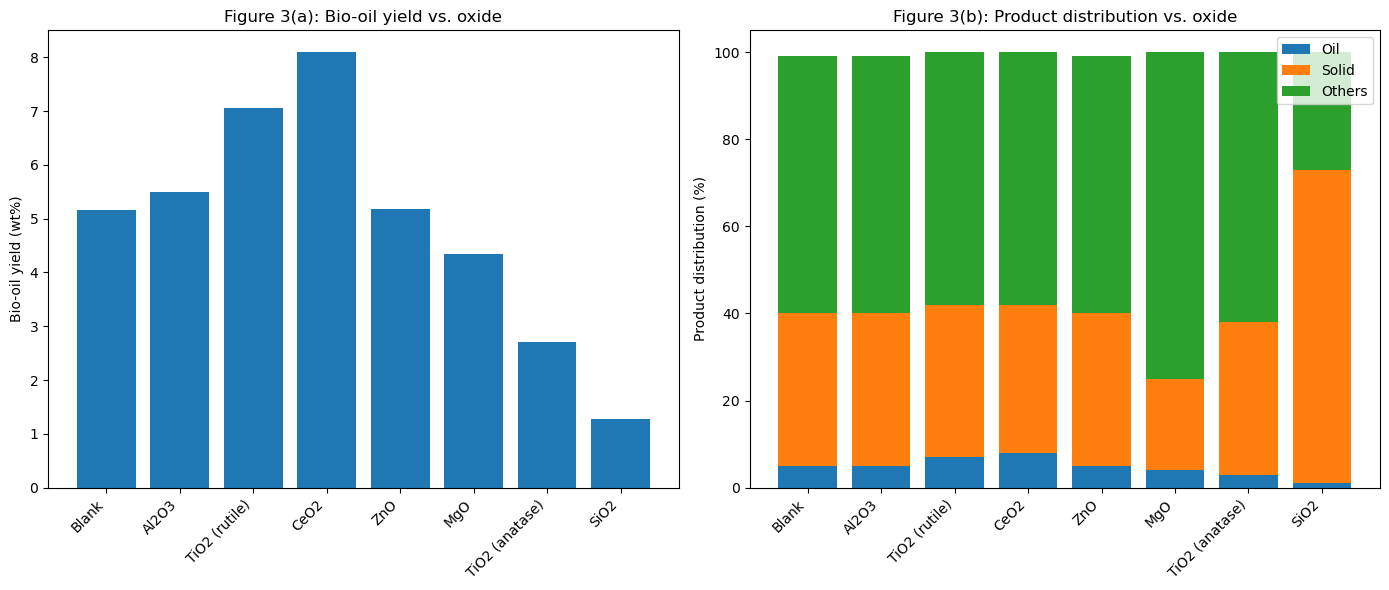

In [3]:
from matplotlib import pyplot as plt
import numpy as np
fig, axes = plt.subplots(1, 2, figsize=(14,6))
# ---- Fig. 3(a): Oil yield ----
oxides_a = [d["Oxide"] for d in FIG3a_Oxide_OilYield]
yields_a = [d["Biooil_wt%"] for d in FIG3a_Oxide_OilYield]

axes[0].bar(oxides_a, yields_a, color="tab:blue")
axes[0].set_ylabel("Bio-oil yield (wt%)")
axes[0].set_title("Figure 3(a): Bio-oil yield vs. oxide")
axes[0].set_xticklabels(oxides_a, rotation=45, ha="right")

# ---- Fig. 3(b): Product distribution ----
oxides_b = [d["Oxide"] for d in FIG3b_ProductDistribution]
oil_b    = [d["Oil_pct"] for d in FIG3b_ProductDistribution]
solid_b  = [d["Solid_pct"] for d in FIG3b_ProductDistribution]
others_b = [d["Others_pct"] for d in FIG3b_ProductDistribution]

x = np.arange(len(oxides_b))
axes[1].bar(x, oil_b, label="Oil", color="tab:blue")
axes[1].bar(x, solid_b, bottom=oil_b, label="Solid", color="tab:orange")
axes[1].bar(x, others_b, bottom=np.array(oil_b)+np.array(solid_b), 
            label="Others", color="tab:green")

axes[1].set_xticks(x)
axes[1].set_xticklabels(oxides_b, rotation=45, ha="right")
axes[1].set_ylabel("Product distribution (%)")
axes[1].set_title("Figure 3(b): Product distribution vs. oxide")
axes[1].legend()

plt.tight_layout()
plt.show()

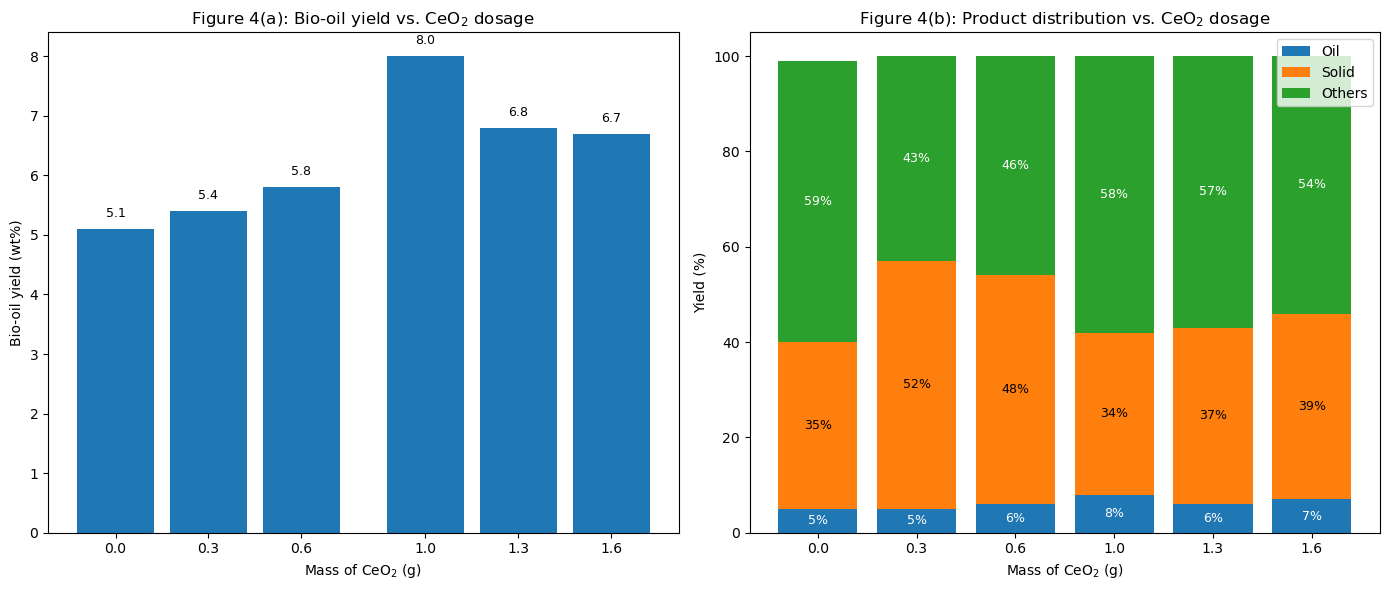

In [4]:
FIG4a_CeO2_Dosage_Biooil = [
    {"CeO2_g":0.0, "Biooil_wt%": 5.1},
    {"CeO2_g":0.3, "Biooil_wt%": 5.4},
    {"CeO2_g":0.6, "Biooil_wt%": 5.8},
    {"CeO2_g":1.0, "Biooil_wt%": 8.0},
    {"CeO2_g":1.3, "Biooil_wt%": 6.8},
    {"CeO2_g":1.6, "Biooil_wt%": 6.7},
]

FIG4b_CeO2_Dosage_Distribution = [
    {"CeO2_g":0.0, "Oil_pct":5, "Solid_pct":35, "Others_pct":59},
    {"CeO2_g":0.3, "Oil_pct":5, "Solid_pct":52, "Others_pct":43},
    {"CeO2_g":0.6, "Oil_pct":6, "Solid_pct":48, "Others_pct":46},
    {"CeO2_g":1.0, "Oil_pct":8, "Solid_pct":34, "Others_pct":58},
    {"CeO2_g":1.3, "Oil_pct":6, "Solid_pct":37, "Others_pct":57},
    {"CeO2_g":1.6, "Oil_pct":7, "Solid_pct":39, "Others_pct":54},
]

from matplotlib import pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14,6))


# ---- Fig. 4(a): CeO2 Dosage vs. Bio-oil yield ----
dosages = [d["CeO2_g"] for d in FIG4a_CeO2_Dosage_Biooil]
yields  = [d["Biooil_wt%"] for d in FIG4a_CeO2_Dosage_Biooil]

axes[0].bar(dosages, yields, width=0.25)
axes[0].set_xlabel("Mass of CeO$_2$ (g)")
axes[0].set_ylabel("Bio-oil yield (wt%)")
axes[0].set_title("Figure 4(a): Bio-oil yield vs. CeO$_2$ dosage")
axes[0].set_xticks(dosages)


for x, y in zip(dosages, yields):
    axes[0].text(x, y + 0.15, f"{y:.1f}", ha="center", va="bottom", fontsize=9)

# ---- Fig. 4(b): Product distribution under different CeO2 dosages ----
oil    = [d["Oil_pct"]    for d in FIG4b_CeO2_Dosage_Distribution]
solid  = [d["Solid_pct"]  for d in FIG4b_CeO2_Dosage_Distribution]
others = [d["Others_pct"] for d in FIG4b_CeO2_Dosage_Distribution]
d2     = [d["CeO2_g"]     for d in FIG4b_CeO2_Dosage_Distribution]

x = np.arange(len(d2))
axes[1].bar(x, oil,   label="Oil")
axes[1].bar(x, solid, bottom=oil,   label="Solid")
axes[1].bar(x, others, bottom=np.array(oil)+np.array(solid), label="Others")

axes[1].set_xticks(x)
axes[1].set_xticklabels([str(v) for v in d2], rotation=0)
axes[1].set_xlabel("Mass of CeO$_2$ (g)")
axes[1].set_ylabel("Yield (%)")
axes[1].set_title("Figure 4(b): Product distribution vs. CeO$_2$ dosage")
axes[1].legend()

for i in range(len(x)):
    y0 = oil[i]
    y1 = oil[i] + solid[i]
    if oil[i] > 0:
        axes[1].text(x[i], oil[i]/2, f"{oil[i]}%", ha="center", va="center", fontsize=9, color="w")
    if solid[i] > 0:
        axes[1].text(x[i], y0 + solid[i]/2, f"{solid[i]}%", ha="center", va="center", fontsize=9, color="k")
    if others[i] > 0:
        axes[1].text(x[i], y1 + others[i]/2, f"{others[i]}%", ha="center", va="center", fontsize=9, color="w")

plt.tight_layout()
plt.show()

/tmp/ipykernel_1601378/315071331.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(catalysts, rotation=45, ha="right")


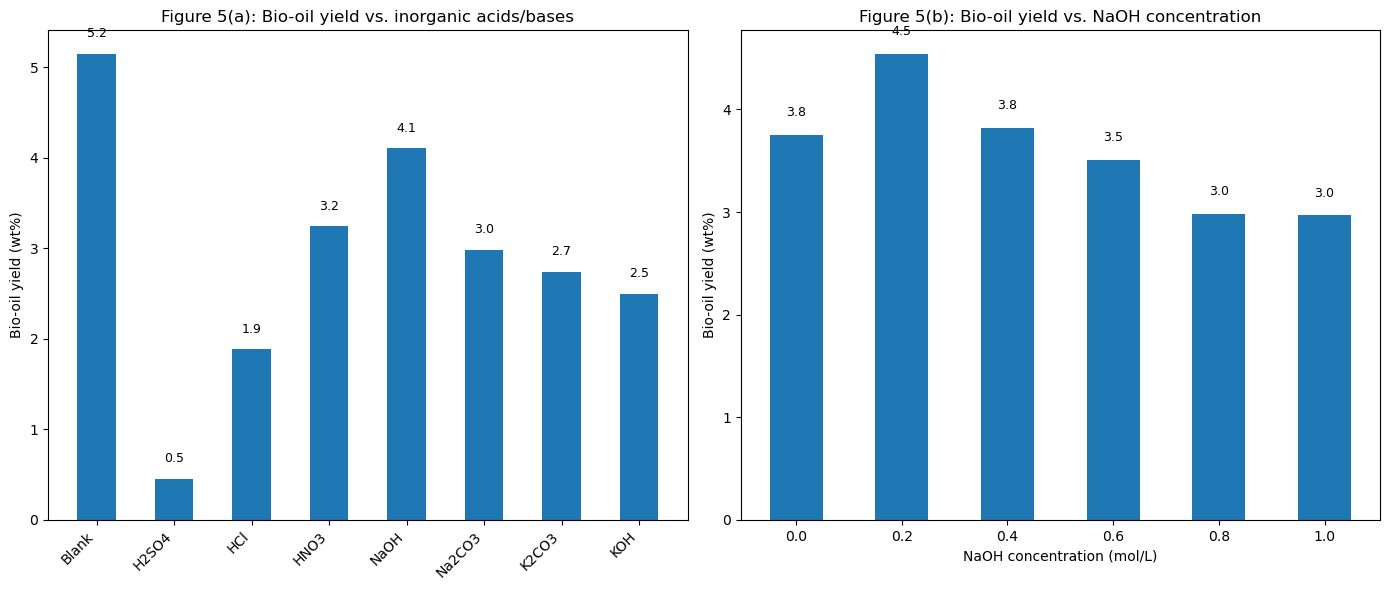

In [5]:
# Figure 5(a) — Bio-oil yield vs inorganic acids/bases
FIG5a_Catalyst_Biooil = [
    {"Catalyst":"Blank",  "Biooil_wt%": 5.152129817444219},
    {"Catalyst":"H2SO4",  "Biooil_wt%": 0.4563894523326584},
    {"Catalyst":"HCl",    "Biooil_wt%": 1.8864097363083174},
    {"Catalyst":"HNO3",   "Biooil_wt%": 3.2454361054766734},
    {"Catalyst":"NaOH",   "Biooil_wt%": 4.1075050709939145},
    {"Catalyst":"Na2CO3", "Biooil_wt%": 2.9817444219066935},
    {"Catalyst":"K2CO3",  "Biooil_wt%": 2.7383367139959436},
    {"Catalyst":"KOH",    "Biooil_wt%": 2.4949290060851927},
]

# Figure 5(b) — Bio-oil yield vs NaOH concentration
# (mol/L on the x-axis: 0, 0.2, 0.4, 0.6, 0.8, 1.0)
FIG5b_NaOH_Conc_Biooil = [
    {"NaOH_mol_L":0.0, "Biooil_wt%": 3.7525354969574036},
    {"NaOH_mol_L":0.2, "Biooil_wt%": 4.543610547667343},
    {"NaOH_mol_L":0.4, "Biooil_wt%": 3.823529411764706},
    {"NaOH_mol_L":0.6, "Biooil_wt%": 3.5091277890466532},
    {"NaOH_mol_L":0.8, "Biooil_wt%": 2.9817444219066935},
    {"NaOH_mol_L":1.0, "Biooil_wt%": 2.9716024340770795},
]
from matplotlib import pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14,6))              
# ---- Fig. 5(a): Bio-oil yield vs. inorganic acids/bases ----
catalysts = [d["Catalyst"] for d in FIG5a_Catalyst_Biooil]
yields    = [d["Biooil_wt%"] for d in FIG5a_Catalyst_Biooil]    
axes[0].bar(catalysts, yields, color="tab:blue", width=0.5)
axes[0].set_ylabel("Bio-oil yield (wt%)")
axes[0].set_title("Figure 5(a): Bio-oil yield vs. inorganic acids/bases")
axes[0].set_xticklabels(catalysts, rotation=45, ha="right")

for x, y in zip(catalysts, yields):
    axes[0].text(x, y + 0.15, f"{y:.1f}", ha="center", va="bottom", fontsize=9)   

# ---- Fig. 5(b): Bio-oil yield vs. NaOH concentration ----
concs = [d["NaOH_mol_L"] for d in FIG5b_NaOH_Conc_Biooil]
yields = [d["Biooil_wt%"] for d in FIG5b_NaOH_Conc_Biooil]
axes[1].bar(concs, yields, width=0.1, color="tab:blue")
axes[1].set_xlabel("NaOH concentration (mol/L)")
axes[1].set_ylabel("Bio-oil yield (wt%)")
axes[1].set_title("Figure 5(b): Bio-oil yield vs. NaOH concentration")
axes[1].set_xticks(concs)

for x, y in zip(concs, yields):     
    axes[1].text(x, y + 0.15, f"{y:.1f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

In [6]:
doi  = "10.3390/en17194854"
prov = "manual extraction"
ref  = "Zhang 2024 — Energies"
Paper_Title  = "Investigation of Cotton Stalk-Derived Hydrothermal Bio-Oil:Effects of Mineral Acid/Base and Oxide Additions"

if "atmosphere" not in df.columns:
    df["atmosphere"] = np.nan

IC = _btw_to_ic("1:10")
REACTOR = "100 mL 316L batch reactor, PTFE-lined"
SEP_TXT = "DCM rinse → vacuum filtration → phase split → rotavap 40 °C"
PRESS_TXT = "autogenic; gas vented (not collected/quantified)"
STIR_RPM = 200
T_SET = 220.0
t_min = 240.0
YIELD_BASIS = "wt% of dry feedstock"

METHODS_Zhang2024 = {
    "Reactor": REACTOR,
    "Stirring_rpm": STIR_RPM,
    "t_min": t_min,
    "T_C": T_SET,
    "Solid_to_liquid": "1:10 (w/w) biomass:water",
    "Gas": "vented, unmeasured",
    "Separation": SEP_TXT,
    "Yield_defs": {
        "B_Y": "bio-oil / dry cotton stalk ×100",
        "C_Y": "solid residue / dry cotton stalk ×100",
        "Others": "100 − B_Y − C_Y (remainder; aqueous + gas)"
    }
}

cs = TABLE1_CS_Elemental.get("CS", {})
df = add_feed(
    df,
    doi=doi, prov=prov, ref=ref, feedstock="Cotton stalk (CS)",
    C=cs.get("C_wt%"), H=cs.get("H_wt%"), O=cs.get("O_wt%"), N=cs.get("N_wt%"), S=cs.get("S_wt%"),
    Ash=cs.get("Ash"), HHV_input=cs.get("HHV_MJkg"),
    lignin=None, cell=None, hemi=None, extract=None, moisture=None,
    source_note="Table 1 — Elemental & HHV (CS feed)"
)

i_feed = df.index[(df["DOI"]==doi) & (df["Feedstock"]=="Cotton stalk (CS)")]
if len(i_feed):
    ex = _safe_json_load(df.at[i_feed[0], "extra"])
    ex.setdefault("provenance", {}).update({
        "notes": "O by difference per paper; HHV via Dulong (paper Eq.4); IC=1:10."
    })
    df.at[i_feed[0], "extra"] = json.dumps(ex, ensure_ascii=False)

_oxide_to_sample = {
    "Blank":           "CS-HT-Oil",
    "SiO2":            "CS-HT-Oil-SiO2",
    "TiO2 (rutile)":   "CS-HT-Oil-TiO2(r.)",
    "TiO2 (anatase)":  "CS-HT-Oil-TiO2(a)",
    "CeO2":            "CS-HT-Oil-CeO2",
    "Al2O3":           "CS-HT-Oil-Al2O3",
    "ZnO":             "CS-HT-Oil-ZnO",
    "MgO":             "CS-HT-Oil-MgO",
}

def _oil_props_for_oxide(label):
    """Return full bio-oil composition (HHV, C, H, O, N, S) for the given oxide label."""
    key = _oxide_to_sample.get(label)
    rec = TABLE1_CS_Elemental.get(key, {}) if key else {}
    return (rec.get("HHV_MJkg"), rec.get("C_wt%"), rec.get("H_wt%"), 
            rec.get("O_wt%"), rec.get("N_wt%"), rec.get("S_wt%"))

_by_from_fig3a = {r["Oxide"]: float(r["Biooil_wt%"]) for r in FIG3a_Oxide_OilYield}

for r in FIG3b_ProductDistribution:
    label = r["Oxide"]
    BY = _by_from_fig3a.get(label, float(r["Oil_pct"]))
    CY = float(r["Solid_pct"])
    others = float(r["Others_pct"])

    HHV_bo, C_bo, H_bo, O_bo, N_bo, S_bo = _oil_props_for_oxide(label)
    catalyst = None if label=="Blank" else label
    proc = "Non-catalytic" if catalyst is None else "Catalytic"

    df = add_or_patch_run(
        df,
        doi=doi, prov=prov, ref=ref, source="Figure 3 — Oxides @ 220 °C, 4 h; Table 1 (oil elemental/HHV)",
        feedstock="Cotton stalk (CS)",
        T=T_SET, t_min=t_min, IC=IC,
        catalyst=catalyst, cat_wt_pct=(0.0 if catalyst is None else None),
        solvent="Water", reactor=REACTOR, sep=SEP_TXT,
        process_subtype=proc, yield_basis=YIELD_BASIS,
        BY=BY, CY=CY, AY=None, GY=None,
        HHV_bo=HHV_bo, C_bo=C_bo, H_bo=H_bo, O_bo=O_bo, N_bo=N_bo, S_bo=S_bo,
        label=f"CS-220C-240min-{label.replace(' ','_')}",
        notes=("Oxide screen" if catalyst else "Blank (no catalyst)"),
        extra={
            "Series": "Oxide screen @220C,240min",
            "others_is_remainder": True,
            "gas_unmeasured": True,
            "Unassigned_Y": others,
            "IC": "1:10 (biomass:water)",
            "Methods": METHODS_Zhang2024
        },
        pressure_text=PRESS_TXT,
        stirring_rpm=STIR_RPM
    )

_dist_by_ceo2 = {round(e["CeO2_g"],3):(e["Oil_pct"], e["Solid_pct"], e["Others_pct"]) for e in FIG4b_CeO2_Dosage_Distribution}

for e in FIG4a_CeO2_Dosage_Biooil:
    m = round(float(e["CeO2_g"]),3)
    BY = float(e["Biooil_wt%"])
    oil_pct, solid_pct, others_pct = _dist_by_ceo2.get(m, (None, None, None))

    df = add_or_patch_run(
        df,
        doi=doi, prov=prov, ref=ref, source="Figure 4 — CeO2 dosage @ 220 °C, 4 h",
        feedstock="Cotton stalk (CS)",
        T=T_SET, t_min=t_min, IC=IC,
        catalyst=f"CeO2 ({m} g)",
        cat_wt_pct=None,
        solvent="Water", reactor=REACTOR, sep=SEP_TXT,
        process_subtype="Catalytic", yield_basis=YIELD_BASIS,
        BY=BY, CY=(None if solid_pct is None else float(solid_pct)),
        AY=None, GY=None,
        HHV_bo=None, C_bo=None,
        label=f"CS-220C-240min-CeO2-{m}g",
        notes="CeO2 dosage sweep; biomass charge not reported → mass ratio unavailable",
        extra={
            "Series": "CeO2 dosage @220C,240min",
            "CeO2_mass_g": m,
            "others_is_remainder": True,
            "gas_unmeasured": True,
            "Unassigned_Y": (None if others_pct is None else float(others_pct)),
            "IC": "1:10 (biomass:water)",
            "Methods": METHODS_Zhang2024
        },
        pressure_text=PRESS_TXT,
        stirring_rpm=STIR_RPM
    )

for e in FIG5a_Catalyst_Biooil:
    cat = e["Catalyst"]
    BY = float(e["Biooil_wt%"])
    catalyst = None if cat=="Blank" else cat
    proc = "Non-catalytic" if catalyst is None else "Catalytic"
    solvent_txt = "Water" if catalyst is None else f"Water + {catalyst} 1.0 M"

    df = add_or_patch_run(
        df,
        doi=doi, prov=prov, ref=ref, source="Figure 5(a) — Inorganic acids/bases @ 1 M",
        feedstock="Cotton stalk (CS)",
        T=T_SET, t_min=t_min, IC=IC,
        catalyst=catalyst, cat_wt_pct=None,
        solvent=solvent_txt,
        reactor=REACTOR, sep=SEP_TXT,
        process_subtype=proc, yield_basis=YIELD_BASIS,
        BY=BY, CY=None, AY=None, GY=None,
        HHV_bo=None, C_bo=None,
        label=f"CS-220C-240min-{cat.replace(' ','_')}",
        notes="Homogeneous catalyst screen at 1 M (product distribution not reported)",
        extra={
            "Series": "Acid/base screen @1M",
            "Conc_M": (None if catalyst is None else 1.0),
            "others_is_remainder": True,
            "gas_unmeasured": True,
            "IC": "1:10 (biomass:water)",
            "Methods": METHODS_Zhang2024
        },
        pressure_text=PRESS_TXT,
        stirring_rpm=STIR_RPM
    )

for e in FIG5b_NaOH_Conc_Biooil:
    conc = float(e["NaOH_mol_L"])
    BY = float(e["Biooil_wt%"])
    catalyst = None if conc==0 else "NaOH"
    proc = "Non-catalytic" if catalyst is None else "Catalytic"
    solvent_txt = "Water" if conc==0 else f"Water + NaOH {conc} M"

    df = add_or_patch_run(
        df,
        doi=doi, prov=prov, ref=ref, source="Figure 5(b) — NaOH concentration @ 220 °C, 4 h",
        feedstock="Cotton stalk (CS)",
        T=T_SET, t_min=t_min, IC=IC,
        catalyst=catalyst, cat_wt_pct=None,
        solvent=solvent_txt,
        reactor=REACTOR, sep=SEP_TXT,
        process_subtype=proc, yield_basis=YIELD_BASIS,
        BY=BY, CY=None, AY=None, GY=None,
        HHV_bo=None, C_bo=None,
        label=f"CS-220C-240min-NaOH-{conc}M",
        notes="NaOH concentration sweep (product distribution not reported)",
        extra={
            "Series": "NaOH concentration @220C,240min",
            "Conc_M": conc if conc>0 else None,
            "others_is_remainder": True,
            "gas_unmeasured": True,
            "IC": "1:10 (biomass:water)",
            "Methods": METHODS_Zhang2024
        },
        pressure_text=PRESS_TXT,
        stirring_rpm=STIR_RPM
    )

df = propagate_and_clean(df.copy())
df = finalize(df.copy())
df["Provenance"]=df["Source_Figure"]
df["Process_subtype"]=" catalytic hydrothermal liquefaction"

/tmp/ipykernel_1601378/254715225.py:110: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat([df, pd.DataFrame([row])], ignore_index=True)
/tmp/ipykernel_1601378/254715225.py:110: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat([df, pd.DataFrame([row])], ignore_index=True)
/tmp/ipykernel_1601378/254715225.py:110: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or al

In [7]:
ACID_BASE_DENSITIES = {
    "SiO2": {"acid":0.006, "base":0.097},
    "TiO2 (rutile)": {"acid":0.039, "base":0.044},
    "CeO2": {"acid":0.036, "base":0.010},
    "Al2O3": {"acid":0.084, "base":0.067},
    "ZnO": {"acid":0.084, "base":0.044},
    "MgO": {"acid":0.150, "base":0.098},
}

ASSUMED_BIOMASS_G = 5.0

def _estimate_ratio(cat):
    if not isinstance(cat,str) or not cat.strip():
        return np.nan
    c = cat.lower()
    if "ceo2" in c and "(" in c and "g" in c:
        try:
            mass_g = float(c.split("(")[1].split("g")[0])
            return round(mass_g / ASSUMED_BIOMASS_G, 3)
        except Exception:
            return np.nan
    for name in ACID_BASE_DENSITIES:
        if name.lower() in c:
            return 0.2
    if any(x in c for x in ["h2so4","hcl","hno3","naoh","koh","na2co3","k2co3"]):
        return 0.1
    return np.nan

df["Catalyst_Biomass_ratio"] = df["Catalyst_Biomass_ratio"].combine_first(
    df["Catalyst"].apply(_estimate_ratio)
)

mask = df["Catalyst_Biomass_ratio"].notna()
for i in df[mask].index:
    ex = _safe_json_load(df.at[i,"extra"])
    ex.setdefault("provenance",{}).setdefault("catalyst_ratio_estimation",
        "Derived from Zhang 2024 SM Table S4 + 1 g oxide per 5 g biomass assumption")
    df.at[i,"extra"] = json.dumps(ex, ensure_ascii=False)

In [8]:
import json

def _series_mask(df, series_name):
    return df["extra"].astype(str).apply(
        lambda s: (json.loads(s).get("Series","") if isinstance(s,str) and s.startswith("{") else "") == series_name
    )

df_sub = df[df["DOI"]==doi].copy()

expected_total = (
    len(FIG3b_ProductDistribution) +
    len(FIG4a_CeO2_Dosage_Biooil) +
    len(FIG5a_Catalyst_Biooil) +
    len(FIG5b_NaOH_Conc_Biooil)
)

print("Rows for Zhang 2024 (this DOI):", len(df_sub), " (expected:", expected_total, ")")

m3 = _series_mask(df_sub, "Oxide screen @220C,240min")
assert m3.sum() == len(FIG3b_ProductDistribution), f"Oxide screen rows {m3.sum()} != {len(FIG3b_ProductDistribution)}"

m4 = _series_mask(df_sub, "CeO2 dosage @220C,240min")
assert m4.sum() == len(FIG4a_CeO2_Dosage_Biooil), f"CeO2 dosage rows {m4.sum()} != {len(FIG4a_CeO2_Dosage_Biooil)}"

m5a = _series_mask(df_sub, "Acid/base screen @1M")
assert m5a.sum() == len(FIG5a_Catalyst_Biooil), f"Acid/base rows {m5a.sum()} != {len(FIG5a_Catalyst_Biooil)}"

m5b = _series_mask(df_sub, "NaOH concentration @220C,240min")
assert m5b.sum() == len(FIG5b_NaOH_Conc_Biooil), f"NaOH conc total {m5b.sum()} != {len(FIG5b_NaOH_Conc_Biooil)}"

have_5b_naoh = df_sub[m5b]["Catalyst"].astype(str).str.contains("NaOH", na=False).sum()
expected_5b_naoh = sum(1 for e in FIG5b_NaOH_Conc_Biooil if e["NaOH_mol_L"] > 0)
assert have_5b_naoh == expected_5b_naoh, f"NaOH>0M rows {have_5b_naoh} != {expected_5b_naoh}"

print("✅ Series counts look good.")

Rows for Zhang 2024 (this DOI): 28  (expected: 28 )
✅ Series counts look good.


In [9]:
len(df)

28

E_H > 25.0 MJ/kg: 0 rows
E_B > 25.0 MJ/kg: 0 rows
B_Y outside [0,100]: 0 rows
C_Y outside [0,100]: 0 rows
C_B > 0.60 (fraction): 0 rows
C_H > 0.65 (fraction): 0 rows
HHV_input < 12 MJ/kg: 0 rows
H/C outside ~[0.8,1.9]: 0 rows
O/C outside ~[0.35,0.95]: 0 rows


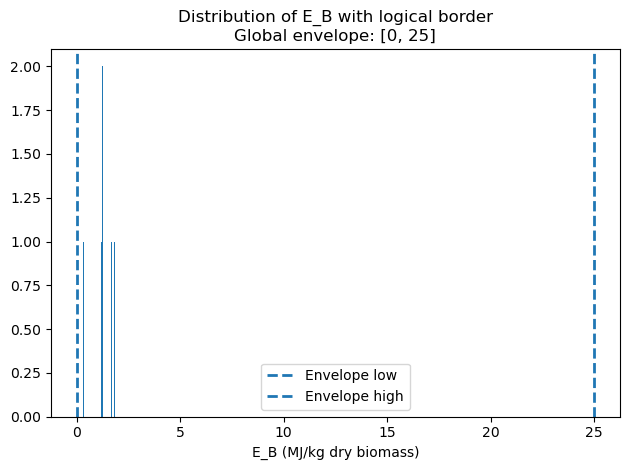

No data to plot for E_H.


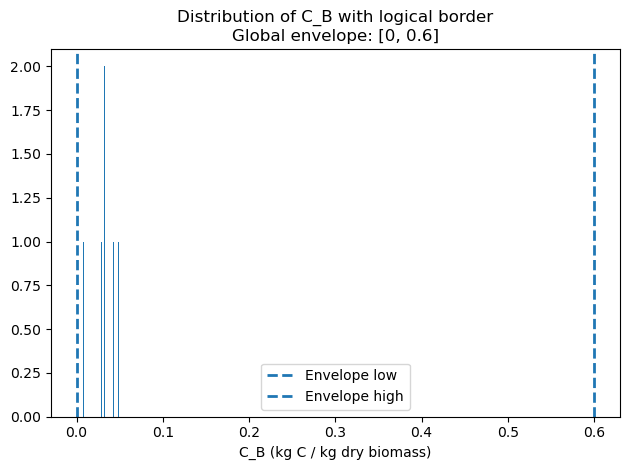

No data to plot for C_H.


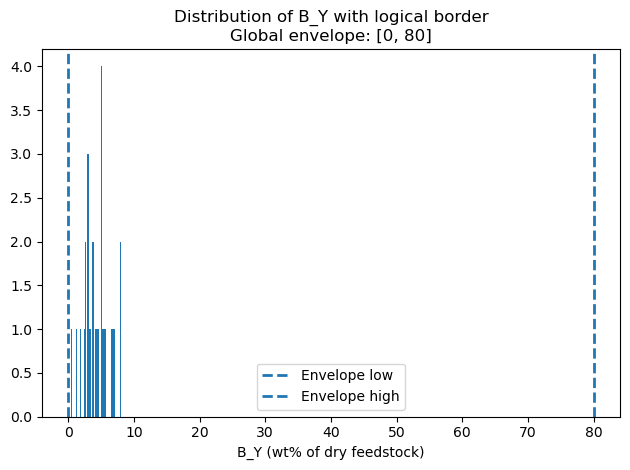

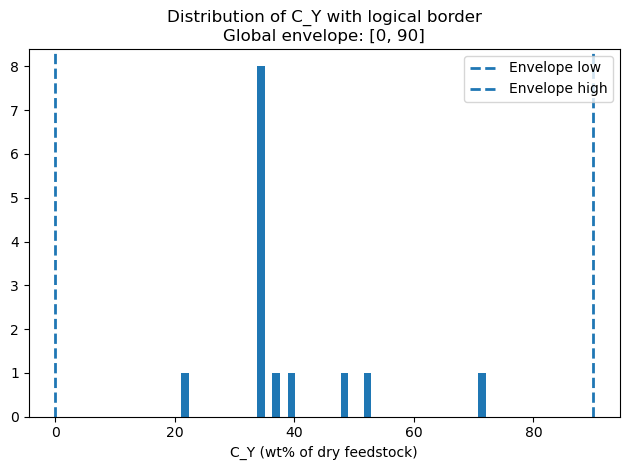

No data to plot for A_Y.
No data to plot for G_Y.


In [10]:
import importlib.util, pathlib, sys

mod_path = pathlib.Path("../../modules/qa_envelopes.py").resolve() 
spec = importlib.util.spec_from_file_location("qa_envelopes", str(mod_path))
qa_envelopes = importlib.util.module_from_spec(spec)
sys.modules["qa_envelopes"] = qa_envelopes
spec.loader.exec_module(qa_envelopes)

qa_envelopes.run_basic_qc(df)
qa_envelopes.plot_energy_carbon_envelopes(df)
qa_envelopes.plot_yield_envelopes(df)

In [11]:
df, ic_audit = qa_envelopes.homogenize_ic_to_percent(
    df,
    bounds=(0.5, 40.0),
    prefer_wbr=True,
    diff_tol_pp=1.0,
    inplace=False,
    dedupe_by_paper=True
)

print(
    ic_audit.sort_values(
        ["rows_out_of_bounds","rows_disagree_wbr","rows_used_wbr"], ascending=False
    ).to_string(index=False)
)

IC homogenization: rows=28, with W/B=28, filled_from_W/B=0, disagreed>1.0pp=0, out_of_bounds[0.5,40.0]=0
       paper_title  rows_total  rows_with_IC_raw  rows_with_WB  rows_used_wbr  rows_disagree_wbr  rows_out_of_bounds  IC_min  IC_max  IC_median  IC_wbr_min  IC_wbr_max
10.3390/en17194854          28                28            28              0                  0                   0    10.0    10.0       10.0    9.090909    9.090909


In [12]:
df["Paper_Title"] = Paper_Title
out_path_csv = Path("./CSVs/Zhang_2024_Energies.csv")
df.to_csv(out_path_csv, index=False)